In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/e2e'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [1]:
def plot_figure(csv_path, metric, y_metric, model_names, model_labels, data_name, system_names, system_labels):
    df = pd.read_csv(csv_path) 
    df = df.groupby(['model_name', 'system_name']).mean().reset_index()
    if 'ttft' in metric:
        df[f'{metric}'] = df[f'{metric}'] / 1000   

    fig = plt.figure(figsize=(3, 2), dpi=120)
    x = np.arange(len(model_names))
    width = 0.15
    ax = fig.add_subplot(111)
    ax.set_xticks(x + width * (len(system_names) - 1) / 2)
    ax.set_xticklabels(model_labels)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for i, system_name in enumerate(system_names):
        if i < 2: 
            ax.bar(x + i * width, 
                  df[f'{metric}'][df['system_name'] == system_name], 
                  width=width, 
                  label=system_labels[i], 
                  color='white', 
                  hatch=hatches[i], 
                  edgecolor='black', 
                  zorder=10)
        else: 
            ax.bar(x + i * width, 
                  df[f'{metric}'][df['system_name'] == system_name], 
                  width=width, 
                  label=system_labels[i], 
                  color=plt.cm.tab20b((i-1)/5), 
                  hatch=hatches[i], 
                  zorder=10, 
                  edgecolor='black',
                  linewidth=0.5)
    for i, model_name in enumerate(model_names):
        # 在bar上添加文本，用最小值进行normalization
        baseline = df[f'{metric}'][df['model_name'] == model_name].min()
        print(f'baseline: {baseline}')
        for j, system_name in enumerate(system_names): 
            value = df[f'{metric}'][(df['system_name'] == system_name) & (df['model_name'] == model_name)].values[0]
            norm_value = value/baseline
            if metric == 'avg_p99_tpot':
                value = value / 1000
            ax.text(x[i] + j * width, value + 0.05, f'{norm_value:.2f}', ha='center', va='bottom', fontsize=10, color='black', rotation=60)    

    ax.set_ylabel(y_metric)
    
    # 只有非brokenaxes时才设置ylim
    if metric != 'avg_p99_tpot':
        ax.set_ylim(0, 1.7 * df[f'{metric}'].max())
    ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    ax.legend(loc=(0.2, 0.73), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{metric}_{data_name}.pdf', bbox_inches='tight')

baseline: 313.16
baseline: 450.958
baseline: 284.90520799999996
baseline: 278.8214655555556
baseline: 257.66
baseline: 167.80999999999997
baseline: 146.5131383333333
baseline: 68.367254


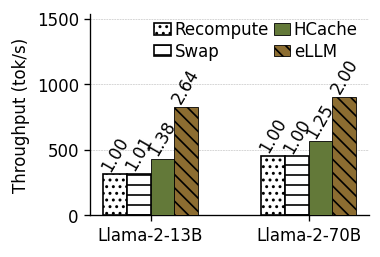

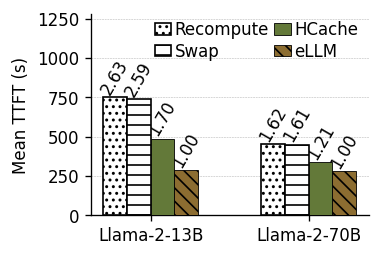

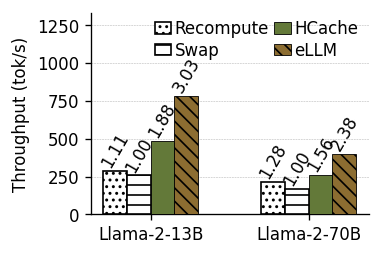

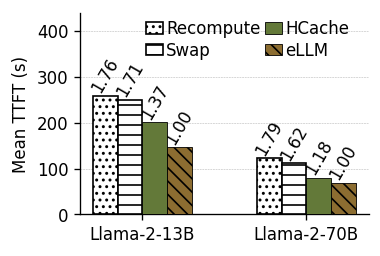

In [5]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
# num_promts = 3024
num_promts = 184
data_names = ['sharegpt','paper_assistant']
# now = datetime.datetime.now()
current_date = '2025-04-22'

metrics = ['avg_output_throughput', 'avg_mean_ttft']
y_metrics = ['Throughput (tok/s)', 'Mean TTFT (s)']
model_labels = ['Llama-2-13B', 'Llama-2-70B']
for data_name in data_names:
    for metric, y_metric in zip(metrics, y_metrics):
        csv_path = f'{DATASET_PATH}/e2e_results_{data_name}_{current_date}.csv' 
        plot_figure(csv_path, metric, y_metric, model_names, model_labels, data_name, system_names, system_labels)

In [110]:
def plot_big_figure(csv_path, metrics, y_metrics, model_names, model_labels, data_name, system_names, system_labels):
    df = pd.read_csv(csv_path) 
    df = df.groupby(['model_name', 'system_name']).mean().reset_index()  

    fig = plt.figure(figsize=(7, 2), dpi=120)
    x = np.arange(len(model_names))
    width = 0.18
    # 绘制三个子图
    ax1 = fig.add_subplot(131)
    ax2 = fig.add_subplot(132)
    ax3 = fig.add_subplot(133)
    axes = [ax1, ax2, ax3]

    for i, ax in enumerate(axes):
        metric = metrics[i]
        y_metric = y_metrics[i]
        if 'ttft' in metric:
            df[f'{metric}'] = df[f'{metric}'] / 1000 
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xticks(x + width * (len(system_names) - 1) / 2)
        ax.set_xticklabels(model_labels)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        for i, system_name in enumerate(system_names):
            if i < 2: 
                ax.bar(x + i * width, 
                    df[f'{metric}'][df['system_name'] == system_name], 
                    width=width, 
                    label=system_labels[i], 
                    color='white', 
                    hatch=hatches[i], 
                    edgecolor='black', 
                    zorder=10)
            else: 
                ax.bar(x + i * width, 
                    df[f'{metric}'][df['system_name'] == system_name], 
                    width=width, 
                    label=system_labels[i], 
                    color=plt.cm.tab20b((i-1)/5), 
                    hatch=hatches[i], 
                    zorder=10, 
                    edgecolor='black',
                    linewidth=0.5)
        if metric == 'slo':
            # bar上绘制真实值
            for i, model_name in enumerate(model_names):
                for j, system_name in enumerate(system_names): 
                    # 真实值
                    value = df[f'{metric}'][(df['system_name'] == system_name) & (df['model_name'] == model_name)].values[0]
                    ax.text(x[i] + j * width, value + 1, f'{value:.1f}', ha='center', va='bottom', fontsize=11, color='black', rotation=80)
            ax.set_ylim(50, 1.2 * df[f'{metric}'].max())
        else:                
            for i, model_name in enumerate(model_names):
                baseline = df[f'{metric}'][df['model_name'] == model_name].min()
                print(f'baseline: {baseline}')
                for j, system_name in enumerate(system_names): 
                    value = df[f'{metric}'][(df['system_name'] == system_name) & (df['model_name'] == model_name)].values[0]
                    norm_value = value/baseline
                    if metric == 'avg_p99_tpot':
                        value = value / 1000
                    ax.text(x[i] + j * width, value + 10, f'{norm_value:.2f}', ha='center', va='bottom', fontsize=11, color='black', rotation=80)    
            ax.set_ylim(0, 1.3 * df[f'{metric}'].max())

        ax.set_ylabel(y_metric)

        # ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    # 绘制一个大图例
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc=(0.3, 0.89), ncol=4, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1.5, handletextpad=0.5, borderaxespad=0.5, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{data_name}.pdf', bbox_inches='tight')

baseline: 313.16
baseline: 450.958
baseline: 284.90520799999996
baseline: 278.8214655555556
baseline: 257.66
baseline: 167.80999999999997
baseline: 146.5131383333333
baseline: 68.367254


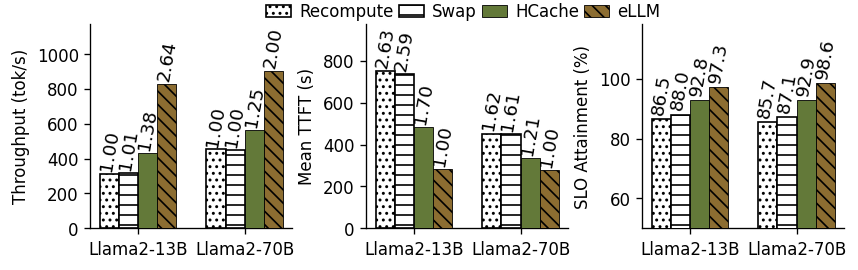

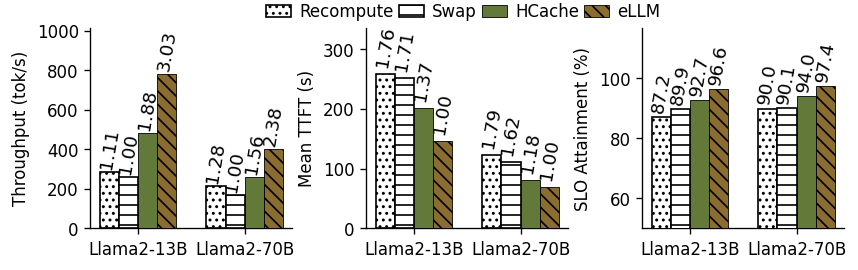

In [113]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'ellm']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
data_names = ['sharegpt', 'paper_assistant']
current_date = '2025-04-22'
metrics = ['avg_output_throughput', 'avg_mean_ttft', 'slo']
y_metrics = ['Throughput (tok/s)', 'Mean TTFT (s)', 'SLO Attainment (%)']
model_labels = ['Llama2-13B', 'Llama2-70B']
for data_name in data_names:
    csv_path = f'{DATASET_PATH}/e2e_results_{data_name}_{current_date}.csv' 
    plot_big_figure(csv_path, metrics, y_metrics, model_names, model_labels, data_name, system_names, system_labels)